<a href="https://colab.research.google.com/github/Chuanhuan/PhD-research/blob/main/kalman_filter_experiments_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ref:
Lecture 7
https://www.wzhanglab.site/teaching/moderncontrolestimation/

# Kalman Filter Experiments: Luenberger Observer vs Kalman Filter

This notebook compares the **Luenberger observer** and the **Kalman filter** for state estimation in systems with noisy measurements.

## System Setup

### Simple Case (No Process Noise)
$$x_{k+1} = x_k, \quad y_k = x_k + v_k$$

### General Case (With Process Noise)
$$x_{k+1} = A x_k + \epsilon_k, \quad y_k = C x_k + v_k$$

Where:
- $x_k$: true state
- $y_k$: noisy measurement  
- $v_k$: measurement noise (white noise)
- $\epsilon_k$: process noise

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility
plt.style.use('seaborn-v0_8-whitegrid')

## Part 1: Simple System ($x_{k+1} = x_k$, no process noise)

### System Dynamics
$$x_{k+1} = x_k$$
$$y_k = x_k + v_k$$

### Luenberger Observer Math
The observer update is:
$$\hat{x}_{k+1} = \hat{x}_k + L(y_k - \hat{x}_k)$$

**Error Dynamics:**
Let $e_k = x_k - \hat{x}_k$. Then:
$$e_{k+1} = x_{k+1} - \hat{x}_{k+1} = x_k - (\hat{x}_k + L(x_k + v_k - \hat{x}_k))$$
$$e_{k+1} = (1 - L)e_k - L v_k$$

**Convergence vs Noise:**
- **Convergence**: Controlled by $(1-L)$. If $|1-L| < 1$, error decays. Smaller $(1-L)$ (i.e., $L$ closer to 1) means faster decay.
- **Noise Sensitivity**: The term $-L v_k$ shows that higher $L$ amplifies measurement noise.

### Simulation Parameters

In [ ]:
# Simulation parameters
N = 100  # Number of time steps
x0 = 0.0  # True initial state
x_hat0 = 1.0  # Initial estimate (wrong on purpose)

# Noise parameters
R = 1.0  # Measurement noise variance (cov(v_k, v_m) = delta_{km})

# Generate true state and noisy measurements
x_true = np.zeros(N)
y = np.zeros(N)
v = np.random.randn(N) * np.sqrt(R)  # Measurement noise

x_true[0] = x0
for k in range(N):
    if k > 0:
        x_true[k] = x_true[k-1]  # x_{k+1} = x_k (constant state)
    y[k] = x_true[k] + v[k]  # Noisy measurement

print(f"True state: {x_true[0]}")
print(f"Measurement noise variance: {R}")
print(f"Sample measurement variance: {np.var(y):.3f}")

True state: 0.0
Measurement noise variance: 1.0
Sample measurement variance: 0.817


### Luenberger Observer Implementation

The Luenberger observer update equation:
$$\hat{x}_{k+1} = \hat{x}_k + L(y_k - \hat{x}_k)$$

Error dynamics: $e(k+1) = (1-L)e(k)$

In [ ]:
def luenberger_observer(y, L, x_hat0):
    """
    Luenberger observer for the simple system x_{k+1} = x_k

    Parameters:
    - y: measurements
    - L: observer gain
    - x_hat0: initial estimate

    Returns:
    - x_hat: state estimates
    """
    N = len(y)
    x_hat = np.zeros(N)
    x_hat[0] = x_hat0

    for k in range(N-1):
        # Observer update: x_hat_{k+1} = x_hat_k + L(y_k - x_hat_k)
        x_hat[k+1] = x_hat[k] + L * (y[k] - x_hat[k])

    return x_hat

# Two different gains
L1 = 0.9  # High gain - fast convergence but sensitive to noise
L2 = 0.1  # Low gain - slow convergence but less sensitive to noise

x_hat_L1 = luenberger_observer(y, L1, x_hat0)
x_hat_L2 = luenberger_observer(y, L2, x_hat0)

print(f"L1 = {L1}: Error decay rate = {1-L1}")
print(f"L2 = {L2}: Error decay rate = {1-L2}")

L1 = 0.9: Error decay rate = 0.09999999999999998
L2 = 0.1: Error decay rate = 0.9


### Kalman Filter Implementation (Simple Case)

For the system $x_{k+1} = x_k$ (A=1, Q=0) and $y_k = x_k + v_k$ (C=1, R=1):

**Predict:**
$$\hat{x}_{k|k-1} = \hat{x}_{k-1|k-1}$$
$$P_{k|k-1} = P_{k-1|k-1} + Q$$

**Update:**
$$K_k = \frac{P_{k|k-1}}{P_{k|k-1} + R}$$
$$\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k(y_k - \hat{x}_{k|k-1})$$
$$P_{k|k} = (1 - K_k)P_{k|k-1}$$

In [ ]:
def kalman_filter_simple(y, R, Q=0, x_hat0=0, P0=1):
    """
    Kalman filter for the simple system x_{k+1} = x_k (A=1, C=1)

    Parameters:
    - y: measurements
    - R: measurement noise variance
    - Q: process noise variance (default 0)
    - x_hat0: initial estimate
    - P0: initial error covariance

    Returns:
    - x_hat: state estimates
    - P: error covariances
    - K: Kalman gains
    """
    N = len(y)
    x_hat = np.zeros(N)
    P = np.zeros(N)
    K = np.zeros(N)

    # Initialize
    x_hat[0] = x_hat0
    P[0] = P0

    for k in range(N):
        if k > 0:
            # Predict
            x_hat_pred = x_hat[k-1]  # A = 1
            P_pred = P[k-1] + Q
        else:
            x_hat_pred = x_hat0
            P_pred = P0

        # Update
        K[k] = P_pred / (P_pred + R)  # Kalman gain
        x_hat[k] = x_hat_pred + K[k] * (y[k] - x_hat_pred)
        P[k] = (1 - K[k]) * P_pred

    return x_hat, P, K

# Run Kalman filter
x_hat_KF, P_KF, K_KF = kalman_filter_simple(y, R, Q=0, x_hat0=x_hat0, P0=1)

print(f"Kalman gain convergence: K_final = {K_KF[-1]:.4f}")
print(f"Final error covariance: P_final = {P_KF[-1]:.4f}")

Kalman gain convergence: K_final = 0.0099
Final error covariance: P_final = 0.0099


### Comparison Plot (Reproducing the Slide)

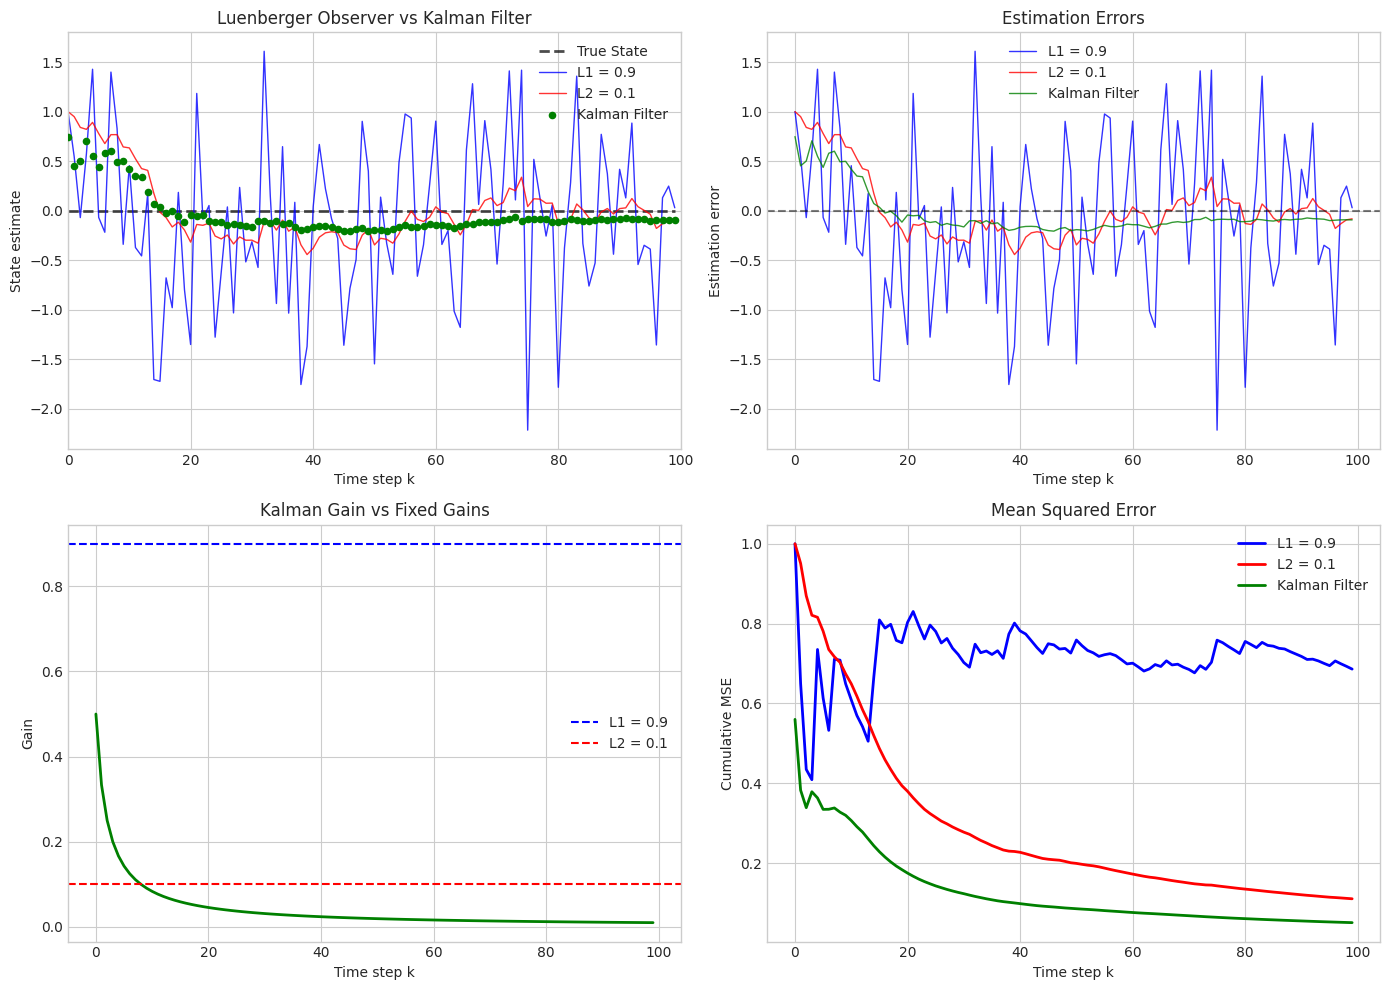


Final MSE:
  L1 = 0.9: MSE = 0.6860
  L2 = 0.1: MSE = 0.1106
  Kalman:  MSE = 0.0508


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: All estimators comparison
ax1 = axes[0, 0]
ax1.plot(x_true, 'k--', linewidth=2, label='True State', alpha=0.7)
ax1.plot(x_hat_L1, 'b-', linewidth=1, label=f'L1 = {L1}', alpha=0.8)
ax1.plot(x_hat_L2, 'r-', linewidth=1, label=f'L2 = {L2}', alpha=0.8)
ax1.scatter(range(N), x_hat_KF, c='g', s=20, label='Kalman Filter', zorder=5)
ax1.set_xlabel('Time step k')
ax1.set_ylabel('State estimate')
ax1.set_title('Luenberger Observer vs Kalman Filter')
ax1.legend(loc='upper right')
ax1.set_xlim([0, N])

# Plot 2: Estimation errors
ax2 = axes[0, 1]
ax2.plot(x_hat_L1 - x_true, 'b-', linewidth=1, label=f'L1 = {L1}', alpha=0.8)
ax2.plot(x_hat_L2 - x_true, 'r-', linewidth=1, label=f'L2 = {L2}', alpha=0.8)
ax2.plot(x_hat_KF - x_true, 'g-', linewidth=1, label='Kalman Filter', alpha=0.8)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Time step k')
ax2.set_ylabel('Estimation error')
ax2.set_title('Estimation Errors')
ax2.legend()

# Plot 3: Kalman gain evolution
ax3 = axes[1, 0]
ax3.plot(K_KF, 'g-', linewidth=2)
ax3.axhline(y=L1, color='b', linestyle='--', label=f'L1 = {L1}')
ax3.axhline(y=L2, color='r', linestyle='--', label=f'L2 = {L2}')
ax3.set_xlabel('Time step k')
ax3.set_ylabel('Gain')
ax3.set_title('Kalman Gain vs Fixed Gains')
ax3.legend()

# Plot 4: Mean Squared Error comparison
ax4 = axes[1, 1]
mse_L1 = np.cumsum((x_hat_L1 - x_true)**2) / np.arange(1, N+1)
mse_L2 = np.cumsum((x_hat_L2 - x_true)**2) / np.arange(1, N+1)
mse_KF = np.cumsum((x_hat_KF - x_true)**2) / np.arange(1, N+1)

ax4.plot(mse_L1, 'b-', linewidth=2, label=f'L1 = {L1}')
ax4.plot(mse_L2, 'r-', linewidth=2, label=f'L2 = {L2}')
ax4.plot(mse_KF, 'g-', linewidth=2, label='Kalman Filter')
ax4.set_xlabel('Time step k')
ax4.set_ylabel('Cumulative MSE')
ax4.set_title('Mean Squared Error')
ax4.legend()

plt.tight_layout()
plt.show()

# Print final MSE values
print(f"\nFinal MSE:")
print(f"  L1 = {L1}: MSE = {mse_L1[-1]:.4f}")
print(f"  L2 = {L2}: MSE = {mse_L2[-1]:.4f}")
print(f"  Kalman:  MSE = {mse_KF[-1]:.4f}")

## Part 2: General Case ($x_t = A x_{t-1} + \epsilon$)

Now we extend to a system with **process noise**:

$$x_{k+1} = A x_k + \epsilon_k, \quad \epsilon_k \sim \mathcal{N}(0, Q)$$
$$y_k = C x_k + v_k, \quad v_k \sim \mathcal{N}(0, R)$$

### Kalman Filter Optimality
The Kalman Filter minimizes the mean squared error $P_k = E[e_k^2]$.

**Prediction Step:**
Increases uncertainty due to process noise:
$$P_{k|k-1} = A P_{k-1|k-1} A^T + Q$$

**Update Step:**
Reduces uncertainty by fusing measurement. The optimal gain $K_k$ is derived by setting $\frac{\partial P_{k|k}}{\partial K_k} = 0$, leading to:
$$K_k = P_{k|k-1} C^T (C P_{k|k-1} C^T + R)^{-1}$$

This gain optimally balances the model uncertainty ($P_{k|k-1}$) and measurement uncertainty ($R$).

In [ ]:
# General system parameters
A = 0.95  # State transition (slightly less than 1 for stability)
C = 1.0   # Measurement matrix
Q = 0.1   # Process noise variance
R = 1.0   # Measurement noise variance

N = 100
x0 = 5.0  # True initial state
x_hat0 = 0.0  # Initial estimate

# Generate true state with process noise
x_true_gen = np.zeros(N)
y_gen = np.zeros(N)
epsilon = np.random.randn(N) * np.sqrt(Q)  # Process noise
v_gen = np.random.randn(N) * np.sqrt(R)    # Measurement noise

x_true_gen[0] = x0
y_gen[0] = C * x_true_gen[0] + v_gen[0]

for k in range(1, N):
    x_true_gen[k] = A * x_true_gen[k-1] + epsilon[k-1]  # Process dynamics
    y_gen[k] = C * x_true_gen[k] + v_gen[k]  # Noisy measurement

print(f"System parameters: A={A}, C={C}")
print(f"Process noise variance Q = {Q}")
print(f"Measurement noise variance R = {R}")

System parameters: A=0.95, C=1.0
Process noise variance Q = 0.1
Measurement noise variance R = 1.0


### General Luenberger Observer

$$\hat{x}_{k+1} = A\hat{x}_k + L(y_k - C\hat{x}_k)$$

In [ ]:
def luenberger_observer_general(y, A, C, L, x_hat0):
    """
    General Luenberger observer for x_{k+1} = A*x_k + epsilon

    Parameters:
    - y: measurements
    - A: state transition matrix (scalar for 1D)
    - C: measurement matrix (scalar for 1D)
    - L: observer gain
    - x_hat0: initial estimate

    Returns:
    - x_hat: state estimates
    """
    N = len(y)
    x_hat = np.zeros(N)
    x_hat[0] = x_hat0

    for k in range(N-1):
        # Observer update: x_hat_{k+1} = A*x_hat_k + L*(y_k - C*x_hat_k)
        x_hat[k+1] = A * x_hat[k] + L * (y[k] - C * x_hat[k])

    return x_hat

# Luenberger observers with different gains
x_hat_L1_gen = luenberger_observer_general(y_gen, A, C, L1, x_hat0)
x_hat_L2_gen = luenberger_observer_general(y_gen, A, C, L2, x_hat0)

### General Kalman Filter

**Predict:**
$$\hat{x}_{k|k-1} = A\hat{x}_{k-1|k-1}$$
$$P_{k|k-1} = A P_{k-1|k-1} A^T + Q$$

**Update:**
$$K_k = P_{k|k-1} C^T (C P_{k|k-1} C^T + R)^{-1}$$
$$\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k(y_k - C\hat{x}_{k|k-1})$$
$$P_{k|k} = (I - K_k C) P_{k|k-1}$$

In [ ]:
def kalman_filter_general(y, A, C, Q, R, x_hat0=0, P0=1):
    """
    General Kalman filter for x_{k+1} = A*x_k + epsilon, y_k = C*x_k + v

    Parameters:
    - y: measurements
    - A: state transition matrix (scalar for 1D)
    - C: measurement matrix (scalar for 1D)
    - Q: process noise variance
    - R: measurement noise variance
    - x_hat0: initial estimate
    - P0: initial error covariance

    Returns:
    - x_hat: state estimates
    - P: error covariances
    - K: Kalman gains
    """
    N = len(y)
    x_hat = np.zeros(N)
    P = np.zeros(N)
    K = np.zeros(N)

    for k in range(N):
        if k == 0:
            # Predict from initial
            x_hat_pred = x_hat0
            P_pred = P0
        else:
            # Predict
            x_hat_pred = A * x_hat[k-1]
            P_pred = A * P[k-1] * A + Q

        # Update
        S = C * P_pred * C + R  # Innovation covariance
        K[k] = P_pred * C / S   # Kalman gain
        x_hat[k] = x_hat_pred + K[k] * (y[k] - C * x_hat_pred)
        P[k] = (1 - K[k] * C) * P_pred

    return x_hat, P, K

# Run general Kalman filter
x_hat_KF_gen, P_KF_gen, K_KF_gen = kalman_filter_general(
    y_gen, A, C, Q, R, x_hat0=x_hat0, P0=10
)

print(f"Steady-state Kalman gain: K_ss ≈ {K_KF_gen[-1]:.4f}")
print(f"Steady-state error covariance: P_ss ≈ {P_KF_gen[-1]:.4f}")

Steady-state Kalman gain: K_ss ≈ 0.2410
Steady-state error covariance: P_ss ≈ 0.2410


### Comparison Plot (General Case)

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2125600/1246811766.py:11: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_title(f'General Case: $x_{{k+1}} = {A}x_k + \epsilon$ (Q={Q}, R={R})')


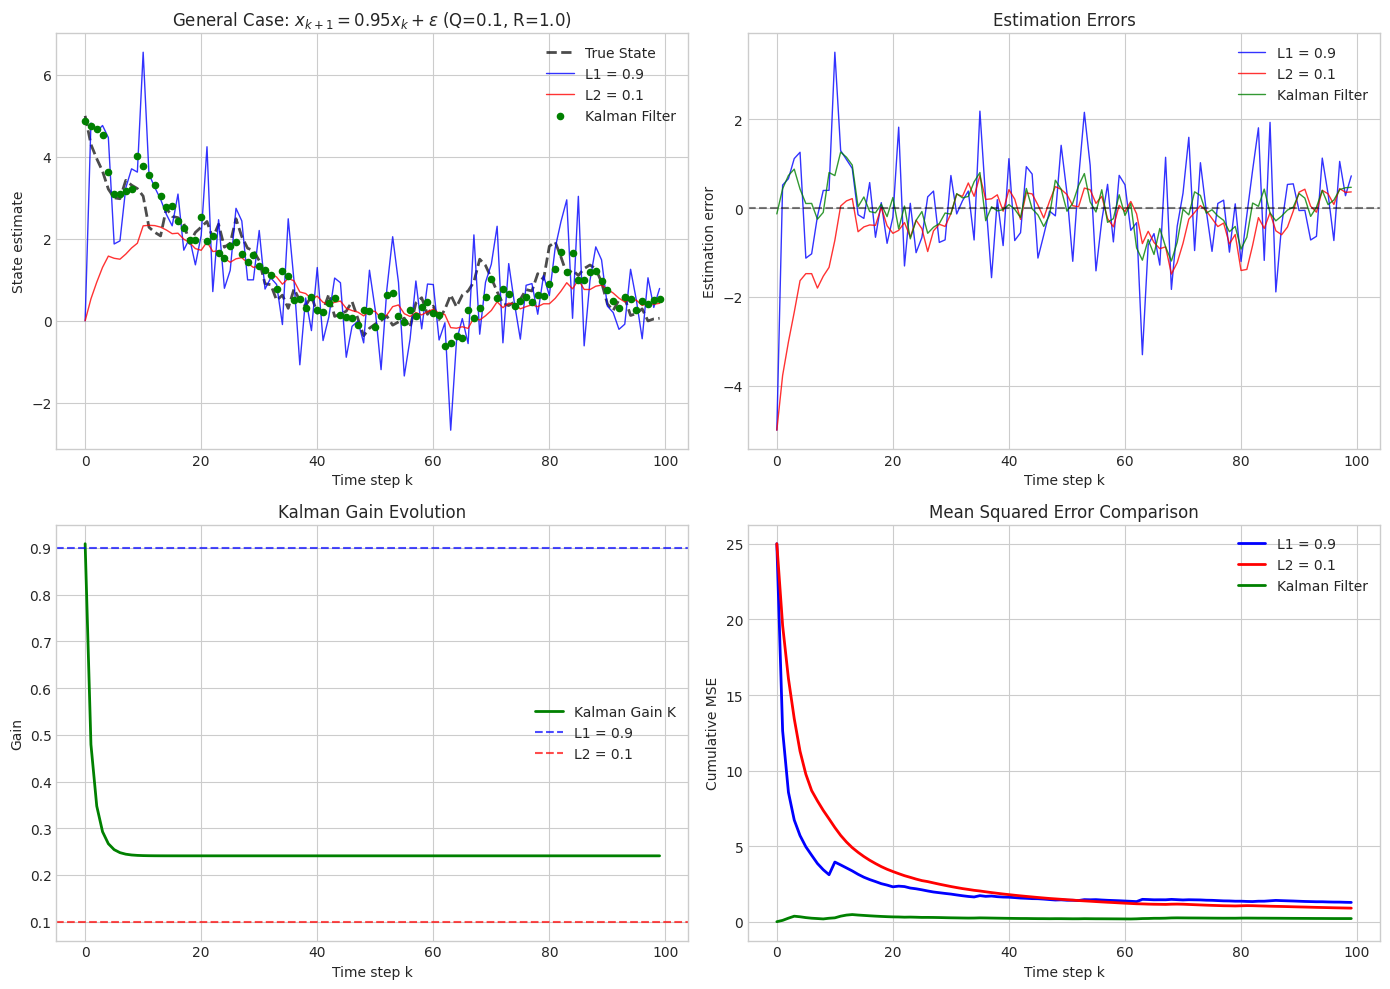


Final MSE (General Case):
  L1 = 0.9: MSE = 1.2908
  L2 = 0.1: MSE = 0.9122
  Kalman:  MSE = 0.2233


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: All estimators comparison
ax1 = axes[0, 0]
ax1.plot(x_true_gen, 'k--', linewidth=2, label='True State', alpha=0.7)
ax1.plot(x_hat_L1_gen, 'b-', linewidth=1, label=f'L1 = {L1}', alpha=0.8)
ax1.plot(x_hat_L2_gen, 'r-', linewidth=1, label=f'L2 = {L2}', alpha=0.8)
ax1.scatter(range(N), x_hat_KF_gen, c='g', s=20, label='Kalman Filter', zorder=5)
ax1.set_xlabel('Time step k')
ax1.set_ylabel('State estimate')
ax1.set_title(f'General Case: $x_{{k+1}} = {A}x_k + \epsilon$ (Q={Q}, R={R})')
ax1.legend(loc='upper right')

# Plot 2: Estimation errors
ax2 = axes[0, 1]
ax2.plot(x_hat_L1_gen - x_true_gen, 'b-', linewidth=1, label=f'L1 = {L1}', alpha=0.8)
ax2.plot(x_hat_L2_gen - x_true_gen, 'r-', linewidth=1, label=f'L2 = {L2}', alpha=0.8)
ax2.plot(x_hat_KF_gen - x_true_gen, 'g-', linewidth=1, label='Kalman Filter', alpha=0.8)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Time step k')
ax2.set_ylabel('Estimation error')
ax2.set_title('Estimation Errors')
ax2.legend()

# Plot 3: Kalman gain and error covariance
ax3 = axes[1, 0]
ax3.plot(K_KF_gen, 'g-', linewidth=2, label='Kalman Gain K')
ax3.axhline(y=L1, color='b', linestyle='--', alpha=0.7, label=f'L1 = {L1}')
ax3.axhline(y=L2, color='r', linestyle='--', alpha=0.7, label=f'L2 = {L2}')
ax3.set_xlabel('Time step k')
ax3.set_ylabel('Gain')
ax3.set_title('Kalman Gain Evolution')
ax3.legend()

# Plot 4: MSE comparison
ax4 = axes[1, 1]
mse_L1_gen = np.cumsum((x_hat_L1_gen - x_true_gen)**2) / np.arange(1, N+1)
mse_L2_gen = np.cumsum((x_hat_L2_gen - x_true_gen)**2) / np.arange(1, N+1)
mse_KF_gen = np.cumsum((x_hat_KF_gen - x_true_gen)**2) / np.arange(1, N+1)

ax4.plot(mse_L1_gen, 'b-', linewidth=2, label=f'L1 = {L1}')
ax4.plot(mse_L2_gen, 'r-', linewidth=2, label=f'L2 = {L2}')
ax4.plot(mse_KF_gen, 'g-', linewidth=2, label='Kalman Filter')
ax4.set_xlabel('Time step k')
ax4.set_ylabel('Cumulative MSE')
ax4.set_title('Mean Squared Error Comparison')
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal MSE (General Case):")
print(f"  L1 = {L1}: MSE = {mse_L1_gen[-1]:.4f}")
print(f"  L2 = {L2}: MSE = {mse_L2_gen[-1]:.4f}")
print(f"  Kalman:  MSE = {mse_KF_gen[-1]:.4f}")

## Part 3: Monte Carlo Analysis

Run multiple simulations to get statistically meaningful MSE comparisons.

In [ ]:
def monte_carlo_comparison(A, C, Q, R, N, n_trials, x0, x_hat0):
    """
    Monte Carlo simulation to compare estimators
    """
    mse_L1_trials = np.zeros(n_trials)
    mse_L2_trials = np.zeros(n_trials)
    mse_KF_trials = np.zeros(n_trials)

    L1, L2 = 0.9, 0.1

    for trial in range(n_trials):
        # Generate new noise realizations
        epsilon = np.random.randn(N) * np.sqrt(Q)
        v = np.random.randn(N) * np.sqrt(R)

        # True state
        x_true = np.zeros(N)
        y = np.zeros(N)
        x_true[0] = x0
        y[0] = C * x_true[0] + v[0]
        for k in range(1, N):
            x_true[k] = A * x_true[k-1] + epsilon[k-1]
            y[k] = C * x_true[k] + v[k]

        # Estimators
        x_hat_L1 = luenberger_observer_general(y, A, C, L1, x_hat0)
        x_hat_L2 = luenberger_observer_general(y, A, C, L2, x_hat0)
        x_hat_KF, _, _ = kalman_filter_general(y, A, C, Q, R, x_hat0, P0=10)

        # MSE
        mse_L1_trials[trial] = np.mean((x_hat_L1 - x_true)**2)
        mse_L2_trials[trial] = np.mean((x_hat_L2 - x_true)**2)
        mse_KF_trials[trial] = np.mean((x_hat_KF - x_true)**2)

    return mse_L1_trials, mse_L2_trials, mse_KF_trials

# Run Monte Carlo simulation
n_trials = 500
print(f"Running {n_trials} Monte Carlo trials...")

mse_L1_mc, mse_L2_mc, mse_KF_mc = monte_carlo_comparison(
    A=0.95, C=1.0, Q=0.1, R=1.0, N=100, n_trials=n_trials, x0=5.0, x_hat0=0.0
)

print(f"\nMonte Carlo Results ({n_trials} trials):")
print(f"  L1 = 0.9: Mean MSE = {np.mean(mse_L1_mc):.4f} ± {np.std(mse_L1_mc):.4f}")
print(f"  L2 = 0.1: Mean MSE = {np.mean(mse_L2_mc):.4f} ± {np.std(mse_L2_mc):.4f}")
print(f"  Kalman:   Mean MSE = {np.mean(mse_KF_mc):.4f} ± {np.std(mse_KF_mc):.4f}")

Running 500 Monte Carlo trials...



Monte Carlo Results (500 trials):
  L1 = 0.9: Mean MSE = 1.1512 ± 0.1297
  L2 = 0.1: Mean MSE = 1.2835 ± 0.2237
  Kalman:   Mean MSE = 0.2539 ± 0.0634


/tmp/ipykernel_2125600/3674521875.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data, labels=['L1=0.9', 'L2=0.1', 'Kalman'], patch_artist=True)


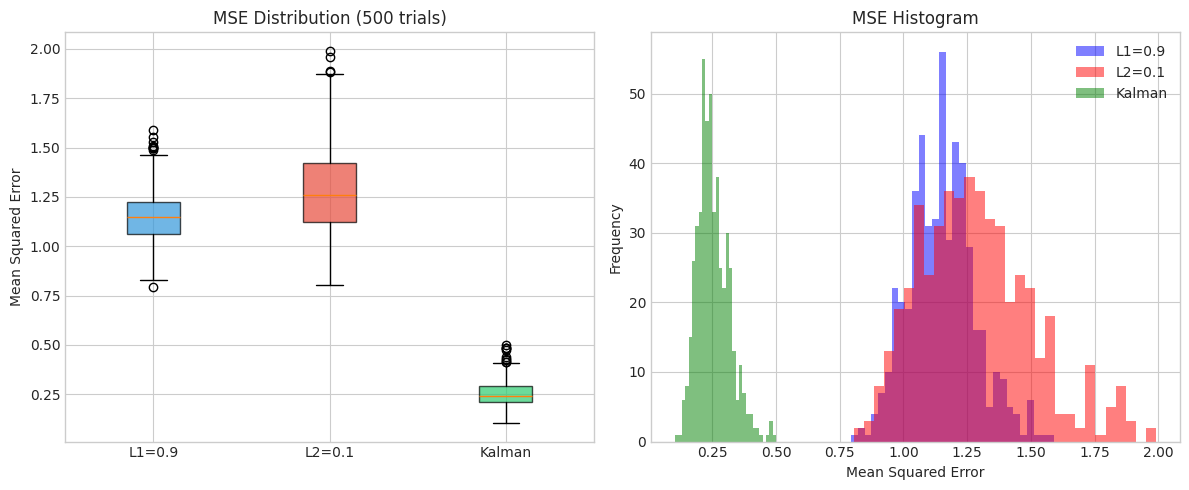

In [ ]:
# Visualization of Monte Carlo results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
ax1 = axes[0]
data = [mse_L1_mc, mse_L2_mc, mse_KF_mc]
bp = ax1.boxplot(data, labels=['L1=0.9', 'L2=0.1', 'Kalman'], patch_artist=True)
colors = ['#3498db', '#e74c3c', '#2ecc71']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('Mean Squared Error')
ax1.set_title(f'MSE Distribution ({n_trials} trials)')

# Histogram
ax2 = axes[1]
ax2.hist(mse_L1_mc, bins=30, alpha=0.5, label='L1=0.9', color='blue')
ax2.hist(mse_L2_mc, bins=30, alpha=0.5, label='L2=0.1', color='red')
ax2.hist(mse_KF_mc, bins=30, alpha=0.5, label='Kalman', color='green')
ax2.set_xlabel('Mean Squared Error')
ax2.set_ylabel('Frequency')
ax2.set_title('MSE Histogram')
ax2.legend()

plt.tight_layout()
plt.show()

## Part 4: Sensitivity Analysis

How does performance change with different Q/R ratios?

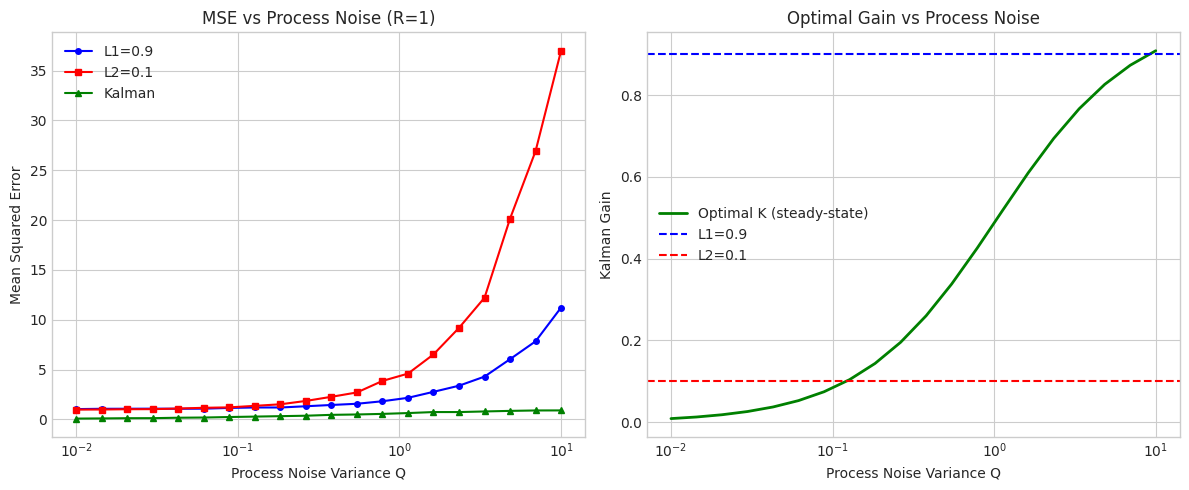


Insight: When Q is low (state changes slowly), low gain L2=0.1 is better.
When Q is high (state changes rapidly), higher gain is needed.
Kalman filter automatically adapts to the optimal gain!


In [ ]:
# Vary Q/R ratio
Q_values = np.logspace(-2, 1, 20)  # Q from 0.01 to 10
R_fixed = 1.0

mse_L1_vary = []
mse_L2_vary = []
mse_KF_vary = []
K_ss_vary = []  # Steady-state Kalman gain

for Q in Q_values:
    mse_L1_mc, mse_L2_mc, mse_KF_mc = monte_carlo_comparison(
        A=0.95, C=1.0, Q=Q, R=R_fixed, N=100, n_trials=50, x0=5.0, x_hat0=0.0
    )
    mse_L1_vary.append(np.mean(mse_L1_mc))
    mse_L2_vary.append(np.mean(mse_L2_mc))
    mse_KF_vary.append(np.mean(mse_KF_mc))

    # Calculate steady-state Kalman gain (theoretical)
    # Solve Riccati equation: P = A^2 * P / (P + R) + Q
    A_val = 0.95
    P_ss = (Q - R + np.sqrt((Q - R)**2 + 4 * A_val**2 * Q * R)) / 2
    K_ss = P_ss / (P_ss + R_fixed)
    K_ss_vary.append(K_ss)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.semilogx(Q_values, mse_L1_vary, 'b-o', label='L1=0.9', markersize=4)
ax1.semilogx(Q_values, mse_L2_vary, 'r-s', label='L2=0.1', markersize=4)
ax1.semilogx(Q_values, mse_KF_vary, 'g-^', label='Kalman', markersize=4)
ax1.set_xlabel('Process Noise Variance Q')
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('MSE vs Process Noise (R=1)')
ax1.legend()
ax1.grid(True)

ax2 = axes[1]
ax2.semilogx(Q_values, K_ss_vary, 'g-', linewidth=2, label='Optimal K (steady-state)')
ax2.axhline(y=0.9, color='b', linestyle='--', label='L1=0.9')
ax2.axhline(y=0.1, color='r', linestyle='--', label='L2=0.1')
ax2.set_xlabel('Process Noise Variance Q')
ax2.set_ylabel('Kalman Gain')
ax2.set_title('Optimal Gain vs Process Noise')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nInsight: When Q is low (state changes slowly), low gain L2=0.1 is better.")
print("When Q is high (state changes rapidly), higher gain is needed.")
print("Kalman filter automatically adapts to the optimal gain!")

## Summary

### Key Findings:

1. **High gain (L1=0.9) amplifies measurement noise** → Large fluctuations in estimates
2. **Low gain (L2=0.1) is smoother** but converges slowly and may not track fast-changing states
3. **Kalman filter is optimal** because it adaptively balances:
   - Trust in the model (when Q is low)
   - Trust in measurements (when R is low)

### Mathematical Insight:

The steady-state Kalman gain for the general system converges to:
$$K_{ss} = \frac{P_{ss}}{P_{ss} + R}$$

where $P_{ss}$ is the solution to the algebraic Riccati equation.

| Scenario | Optimal Strategy |
|----------|------------------|
| Low Q (slow state change) | Low gain - trust model |
| High Q (fast state change) | High gain - follow measurements |
| Low R (accurate measurements) | High gain - trust measurements |
| High R (noisy measurements) | Low gain - trust model |

## Part 5: Comparison with Open Loop (Mean) Estimator

### 1. System Setup & Parameters
We use the following parameters for this comparison:
- **State Transition ($A$)**: 0.95 (System is stable but decays slowly)
- **Measurement Matrix ($C$)**: 1.0 (Direct measurement)
- **Process Noise ($Q$)**: 0.1 (Significant model uncertainty)
- **Measurement Noise ($R$)**: 1.0 (Noisy measurements)

Equations:
$$x_{k+1} = 0.95 x_k + \epsilon_k, \quad \epsilon_k \sim \mathcal{N}(0, 0.1)$$
$$y_k = 1.0 x_k + v_k, \quad v_k \sim \mathcal{N}(0, 1.0)$$

### 2. Open Loop Estimator (Assuming the Mean)
The Open Loop estimator (or Dead Reckoning) trusts the model completely and ignores measurements:
$$\hat{x}_{k+1}^{OL} = 0.95 \hat{x}_k^{OL}$$

**Error Dynamics:**
Define the estimation error $e_k = \hat{x}_k^{OL} - x_k$.
$$e_{k+1} = 0.95 e_k - \epsilon_k$$

**Error Variance ($P_k^{OL}$):**
$$P_{k+1}^{OL} = 0.95^2 P_k^{OL} + 0.1 = 0.9025 P_k^{OL} + 0.1$$

> **Insight:** Even though $A < 1$ provides some stability, the variance settles at a non-zero steady state $P_{ss} = Q / (1 - A^2) \approx 0.1 / (1 - 0.9025) \approx 1.02$. If $A=1$, it would grow to infinity.

### 3. Kalman Filter
The Kalman Filter adds a correction step:
**Predict:** $P_{k|k-1} = 0.9025 P_{k-1|k-1} + 0.1$
**Update:** $P_{k|k} = (1 - K_k) P_{k|k-1}$

> **Insight:** The update step actively reduces variance at every step using the measurement, resulting in a much lower steady-state error variance than the Open Loop estimator.

### 4. Conclusion
The Open Loop estimator is **always worse** than the Kalman Filter (unless $Q=0$, i.e., a perfect model with no process noise). The Kalman Filter uses measurements to "vent" the accumulated uncertainty.

In [ ]:
def open_loop_estimator(A, x_hat0, N):
    """Predicts state based ONLY on the model x_{k+1} = A x_k"""
    x_hat = np.zeros(N)
    x_hat[0] = x_hat0
    for k in range(1, N):
        x_hat[k] = A * x_hat[k-1]
    return x_hat

def measurement_only_estimator(y, C):
    """Estimates state based ONLY on measurements y_k = C x_k"""
    return y / C

# Simulation parameters
N = 100
A = 0.95
C = 1.0
Q = 0.1   # Process noise
R = 1.0   # Measurement noise
x0 = 5.0
x_hat0 = 0.0

# Generate data
np.random.seed(123)
x_true = np.zeros(N)
y = np.zeros(N)
epsilon = np.random.randn(N) * np.sqrt(Q)
v = np.random.randn(N) * np.sqrt(R)

x_true[0] = x0
y[0] = C * x_true[0] + v[0]
for k in range(1, N):
    x_true[k] = A * x_true[k-1] + epsilon[k-1]
    y[k] = C * x_true[k] + v[k]

# Run Estimators
x_ol = open_loop_estimator(A, x_hat0, N)
x_meas = measurement_only_estimator(y, C)
x_kf, _, _ = kalman_filter_general(y, A, C, Q, R, x_hat0, P0=10)

# Calculate MSE
mse_ol = np.mean((x_ol - x_true)**2)
mse_meas = np.mean((x_meas - x_true)**2)
mse_kf = np.mean((x_kf - x_true)**2)

print(f"MSE Comparison:")
print(f"  Open Loop (Model only):       {mse_ol:.4f}")
print(f"  Measurement Only (Data only): {mse_meas:.4f}")
print(f"  Kalman Filter (Fused):        {mse_kf:.4f}")

MSE Comparison:
  Open Loop (Model only):       3.2338
  Measurement Only (Data only): 0.9414
  Kalman Filter (Fused):        0.2630


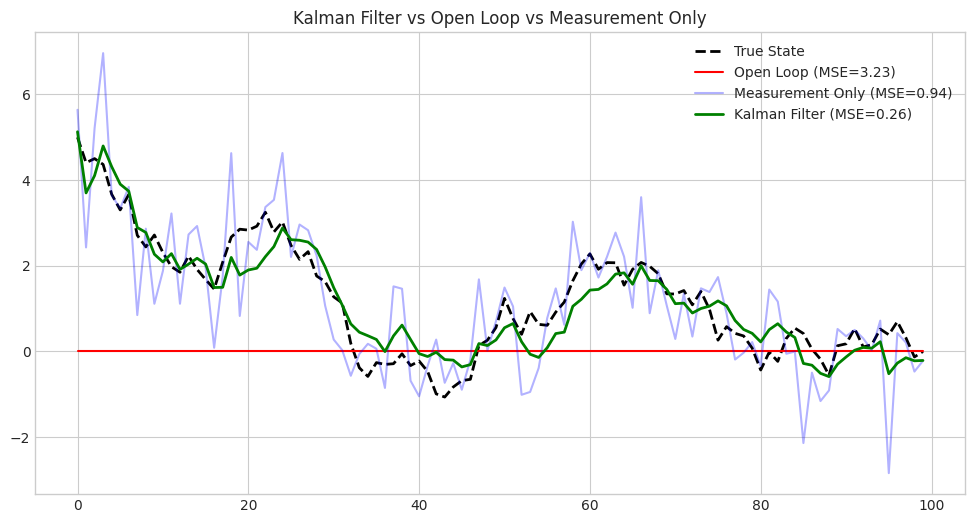

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(x_true, 'k--', linewidth=2, label='True State')
plt.plot(x_ol, 'r-', label=f'Open Loop (MSE={mse_ol:.2f})')
plt.plot(x_meas, 'b-', alpha=0.3, label=f'Measurement Only (MSE={mse_meas:.2f})')
plt.plot(x_kf, 'g-', linewidth=2, label=f'Kalman Filter (MSE={mse_kf:.2f})')
plt.title('Kalman Filter vs Open Loop vs Measurement Only')
plt.legend()
plt.grid(True)
plt.show()